# CLIP 介绍

CLIP（Contrastive Language-Image Pre-training，对比语言-图像预训练）是由 OpenAI 在 2021 年提出的一种革命性的多模态神经网络模型。它的核心目标是弥合计算机视觉（CV）与自然语言处理（NLP）之间的鸿沟，让模型能够像人类一样，<mark>通过自然语言来理解和关联视觉概念</mark>。

CLIP 的核心思想是对比学习（Contrastive Learning）。它通过一个联合训练的过程，将图像和文本映射到同一个高维的语义嵌入空间（Embedding Space）中。

- 在这个空间中，模型会最大化匹配的图像-文本对（正样本）之间的相似度（使它们在空间中靠近）。

<mark>**图片和文本虽然来自不同模态，但它们在共同的语义空间中完成了对齐。**</mark>

- 无需人工标注

- 强大的 zero-shot 迁移学习能力

# CLIP 流程

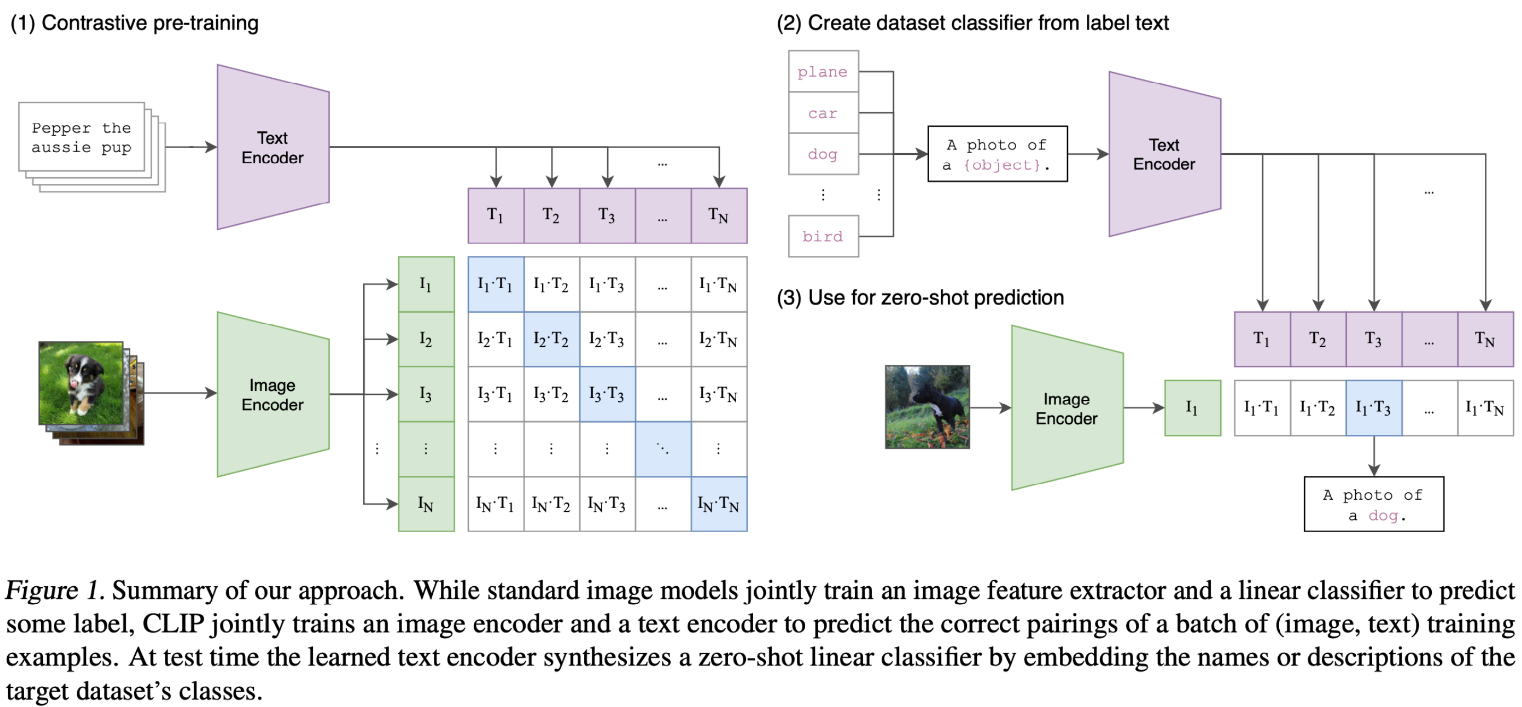

## 数据集构造

**构造 Image-Text 对数据集：**

- 从英文 Wikipedia 中找到所有出现次数>100的单词，作为 querylist。

- 构造 query 集合，大小为 50万。

- 对于每个 query，从搜索引擎找到与它相关的图片。为了保证 query 数据相对平衡，控制每个 query 图片最多保留 2w 个 image-text 对。

- 生成的数据集被称为 WIT（WebImageText）。它和GPT2使用的 WebText 含有相同量级的单词数目。

## 预训练阶段

利用<mark>对比学习</mark>的思想，只预测哪段文本作为一个整体是和图片成对出现的，不需要预测文本的确切内容。


- Image 经过 Image Encoder 抽取图像特征，得到图片特征向量。
- Text 经过 Text Encoder 抽取文本特征，得到文本特征向量。

以上特征通过矩阵乘法（简单的线性映射）投影到多模态特征空间。

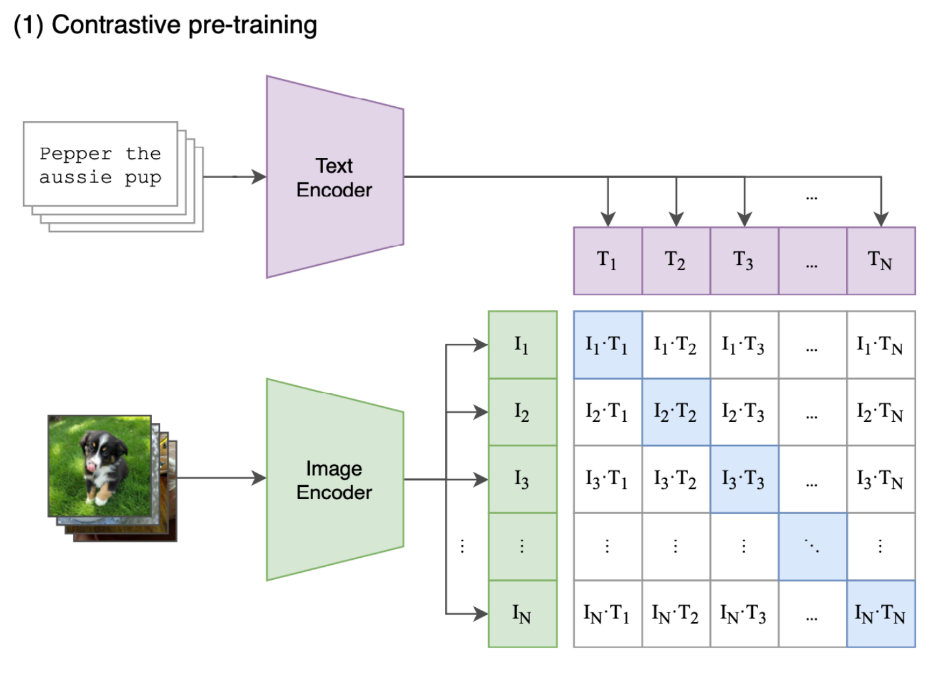

最大化对角线的余弦相似度：$\cos(s) = (a \cdot b)/(\|a\| \cdot \|b\|)$

损失函数：InfoNCE（信息对比损失）

- 将batch中每个图像的正确文本作为正样本
- 将batch中其他N-1个文本作为负样本
- 通过最大化正样本对的相似度、最小化负样本对的相似度，模型在隐式地最大化不同模态间的互信息

## 推理阶段

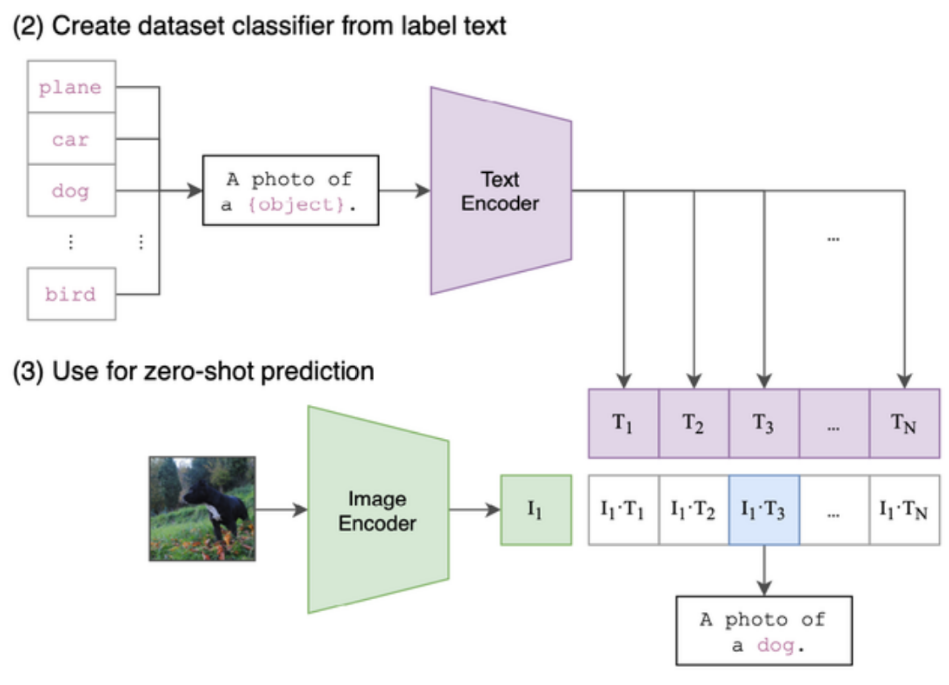

$T_1$ 到 $T_N$ 是 N 个代表 “A photo of a {$Object_i$}”的 embedding 向量：
```text
Embedding_{A photo of a plane.}
Embedding_{A photo of a car.}
...
```

而图片只有一个，我们要看哪个文字向量与图片向量的余弦相似度最大(选择题)


# 总结

## CLIP 的局限性

- 仅关注全局匹配，缺乏更细粒度的语义对齐

    只知道图片是猫，不知道猫在图中的位置

- 没有对文本的深层理解，仅仅将其转化为固定维度的向量，无法处理复杂的文本推理任务

- 对 Prompt 敏感

- 计算开销大，局部特征理解差

    无法定位图片中的目标，只能全局匹配